In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
dataset_dir = "flowers"

In [ ]:
img_size = (299, 299)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

valid_generator = train_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 4289 images belonging to 18 classes.
Found 1068 images belonging to 18 classes.


In [11]:
inception_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

for layer in inception_model.layers:
    layer.trainable = False

num_classes = len(train_generator.class_indices)
model = models.Sequential([
    inception_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#model.summary()

In [7]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator
)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4975 - loss: 1.7789

C:\Users\Melih\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


135/135 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.4982 - loss: 1.7760 - val_accuracy: 0.7425 - val_loss: 0.8091
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.7363 - loss: 0.8300 - val_accuracy: 0.8230 - val_loss: 0.5928
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7714 - loss: 0.7095 - val_accuracy: 0.8436 - val_loss: 0.5141
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7867 - loss: 0.6542 - val_accuracy: 0.8380 - val_loss: 0.5290
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7887 - loss: 0.6743 - val_accuracy: 0.8399 - val_loss: 0.4770
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7941 - loss: 0.6478 - val_accuracy: 0.8343 - val_loss: 0.4922
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.8135 - loss: 0.5562 - val_accuracy: 0.8464 - val_loss: 0.4416
Epoch 8/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.8138 - loss: 0.5356 - val_accuracy: 0.836

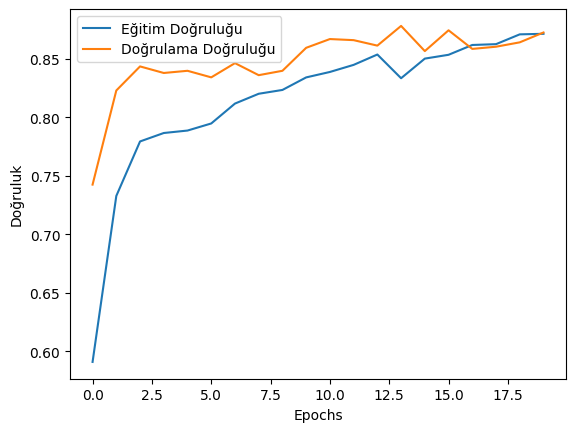

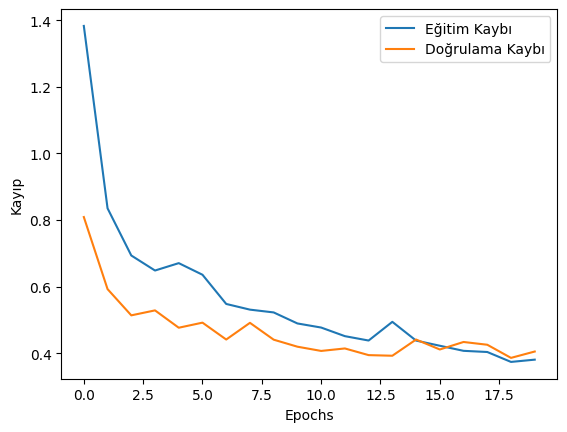

In [ ]:
plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
plt.xlabel('Epochs')
plt.ylabel('Doğruluk')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.xlabel('Epochs')
plt.ylabel('Kayıp')
plt.legend()
plt.show()

In [ ]:
test_generator = test_datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Doğruluğu: {test_acc * 100:.2f}%")

Found 5357 images belonging to 18 classes.
168/168 ━━━━━━━━━━━━━━━━━━━━ 119s 708ms/step - accuracy: 0.9306 - loss: 0.2228
Test Doğruluğu: 92.87%


In [ ]:
model.save('inceptionV3.h5')